In [1]:
from google.colab import files
uploaded = files.upload()

Saving bank+marketing.zip to bank+marketing.zip


In [2]:
import zipfile
import os

zip_path = 'bank+marketing.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('data')

print(os.listdir('data'))

['bank.zip', 'bank-additional.zip']


In [4]:
import pandas as pd
import zipfile
import os

# Define the path to the nested zip file
bank_zip_path = 'data/bank.zip'
# Define the directory where the contents of bank.zip will be extracted
extract_dir = 'data/bank_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Extract bank.zip
with zipfile.ZipFile(bank_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Now, read the bank-full.csv from the newly extracted directory
df = pd.read_csv(os.path.join(extract_dir, 'bank-full.csv'), sep=';')  # use ';' for this dataset

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df['Visited'] = 1

df['Signed Up'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

df['Purchased'] = df['Signed Up']  # or refine if needed

In [6]:
visits = df['Visited'].sum()
signup = df['Signed Up'].sum()
purchase = df['Purchased'].sum()

print("Visit → Signup:", signup/visits)
print("Signup → Purchase:", purchase/signup if signup != 0 else 0)

Visit → Signup: 0.11698480458295547
Signup → Purchase: 1.0


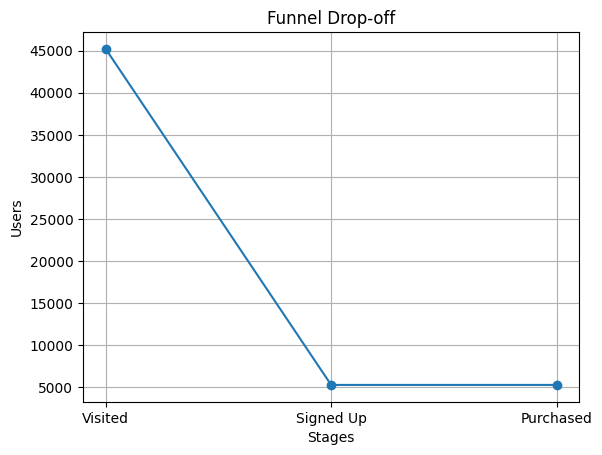

In [15]:
import matplotlib.pyplot as plt

stages = ['Visited','Signed Up','Purchased']
values = [visits, signup, purchase]

plt.figure()
plt.plot(stages, values, marker='o')
plt.title('Funnel Drop-off')
plt.xlabel('Stages')
plt.ylabel('Users')
plt.grid()

plt.savefig('funnel_chart.png')
plt.show()

In [8]:
df['Channel'] = df['contact']

In [9]:
channel = df.groupby('Channel')[['Visited','Signed Up','Purchased']].sum()
channel

,Visited,Signed Up,Purchased
Channel,,,
cellular,29285,4369,4369
telephone,2906,390,390
unknown,13020,530,530


<Figure size 640x480 with 0 Axes>

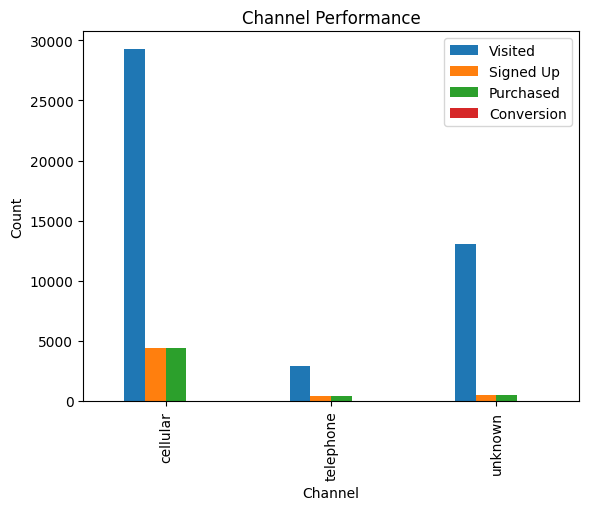

In [16]:
plt.figure()
channel.plot(kind='bar')
plt.title('Channel Performance')
plt.ylabel('Count')

plt.savefig('channel_performance.png')
plt.show()

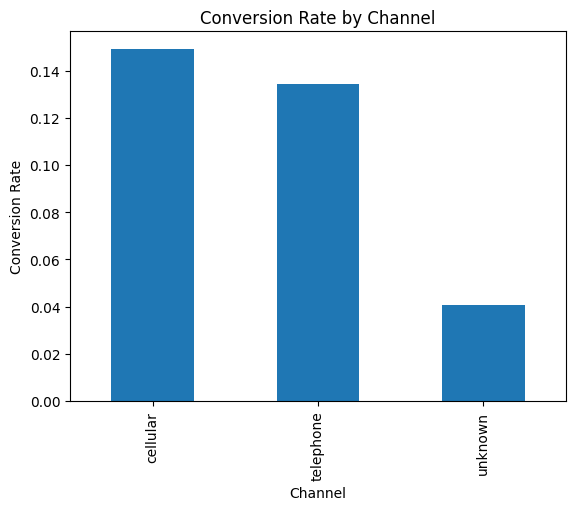

In [17]:
plt.figure()
channel['Conversion'].plot(kind='bar')
plt.title('Conversion Rate by Channel')
plt.ylabel('Conversion Rate')

plt.savefig('conversion_by_channel.png')  # ✅ SAVE
plt.show()

In [12]:
df.to_csv('cleaned_data.csv', index=False)

In [13]:
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
df.groupby('job')['Purchased'].mean().sort_values(ascending=False)

,Purchased
job,
student,0.286780
retired,0.227915
unemployed,0.155027
management,0.137556
admin.,0.122027
self-employed,0.118429
unknown,0.118056
technician,0.110570
services,0.088830


In [18]:
from google.colab import files

files.download('funnel_chart.png')
files.download('channel_performance.png')
files.download('conversion_by_channel.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
requirements = """pandas>=1.5.0
matplotlib>=3.7.0
numpy>=1.23.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

In [20]:
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>